# Amazon AI Enterprise Risk Assessment – Complete Analytics Notebook

This notebook is designed to support the PPT version of the Amazon AI Enterprise Risk Assessment.

It includes all major analytics visuals used in the presentation:
- Integrated situation assessment chart
- Qualitative probability-impact view
- Expected loss ranking
- Top quantified exposures
- ML model validation
- ML feature importance
- Logistic regression coefficients
- Monte Carlo simulation with 100,000 trials
- Annual loss distribution
- Exceedance probability chart
- Severe loss / tail-risk contribution
- KRI trigger table

Put this notebook in the same folder as the CSV files, then run all cells.

In [1]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 120)

FIG_DIR = Path("figures")
FIG_DIR.mkdir(exist_ok=True)

print("Current working directory:")
print(os.getcwd())
print("\nFiles in this folder:")
print(os.listdir())

Current working directory:
C:\Users\lenovo\ALY6130\final

Files in this folder:
['.ipynb_checkpoints', 'amazon_ai_enterprise_risk_complete_notebook.ipynb', 'data', 'eda.ipynb', 'figures', 'ml_feature_importance.csv', 'ml_logistic_coefficients.csv', 'ml_model_metrics.csv', 'monte_carlo.ipynb', 'monte_carlo_summary.csv', 'qualitative_analysis.ipynb', 'quantitative_analysis.ipynb', 'quantitative_risk_summary.csv', 'synthetic_ml_dataset.csv', 'tail_contribution.csv']


## 1. Load Project Data

In [2]:
def find_file(filename):
    # Robust file finder:
    # 1. current folder
    # 2. data/processed
    # 3. ../data/processed
    # 4. /mnt/data for ChatGPT sandbox
    candidates = [
        Path(filename),
        Path("data") / "processed" / filename,
        Path("..") / "data" / "processed" / filename,
        Path("/mnt/data") / filename,
    ]

    stem = Path(filename).stem
    suffix = Path(filename).suffix
    if Path("/mnt/data").exists():
        candidates.extend(sorted(Path("/mnt/data").glob(f"{stem}*{suffix}")))

    for path in candidates:
        if path.exists():
            print(f"Loaded {filename} from: {path}")
            return path

    raise FileNotFoundError(f"Could not find {filename}")

quant = pd.read_csv(find_file("quantitative_risk_summary.csv"))
mc_summary = pd.read_csv(find_file("monte_carlo_summary.csv"))
tail = pd.read_csv(find_file("tail_contribution.csv"))
ml_metrics = pd.read_csv(find_file("ml_model_metrics.csv"))
feature_importance = pd.read_csv(find_file("ml_feature_importance.csv"))
logistic_coef = pd.read_csv(find_file("ml_logistic_coefficients.csv"))
ml_data = pd.read_csv(find_file("synthetic_ml_dataset.csv"))

print("\nData shapes:")
print("quant:", quant.shape)
print("mc_summary:", mc_summary.shape)
print("tail:", tail.shape)
print("ml_metrics:", ml_metrics.shape)
print("feature_importance:", feature_importance.shape)
print("logistic_coef:", logistic_coef.shape)
print("ml_data:", ml_data.shape)

Loaded quantitative_risk_summary.csv from: quantitative_risk_summary.csv
Loaded monte_carlo_summary.csv from: monte_carlo_summary.csv
Loaded tail_contribution.csv from: tail_contribution.csv
Loaded ml_model_metrics.csv from: ml_model_metrics.csv
Loaded ml_feature_importance.csv from: ml_feature_importance.csv
Loaded ml_logistic_coefficients.csv from: ml_logistic_coefficients.csv
Loaded synthetic_ml_dataset.csv from: synthetic_ml_dataset.csv

Data shapes:
quant: (10, 14)
mc_summary: (1, 8)
tail: (10, 2)
ml_metrics: (2, 6)
feature_importance: (11, 2)
logistic_coef: (11, 2)
ml_data: (1200, 12)


In [3]:
display(quant.head())
display(mc_summary)
display(ml_metrics)

,Risk,Risk Name,Category,Mean Probability,Beta alpha,Beta beta,Impact min $m,Impact mode $m,Impact max $m,Expected Impact $m,Expected Loss $m,Loss Variance,P90 Loss $m,P95 Loss $m
0,Risk 1,Competitor AI Advantage,Strategic,0.34,34,66,70,160,360,196.666667,66.866667,521.168044,99.062378,108.826817
1,Risk 2,AI Warehouse Strategy Failure,Strategic and operational,0.30,30,70,80,220,500,266.666667,80.000000,850.378190,120.615209,133.316357
2,Risk 3,Cybersecurity & Data Breach,Information security,0.22,22,78,120,320,950,463.333333,101.933333,1958.612512,164.592792,185.377677
3,Risk 4,AI Forecasting Failure,Technology and operational,0.28,28,72,40,120,300,153.333333,42.933333,284.128143,66.476927,74.173550
4,Risk 5,System Integration Failure,Technology and operational,0.26,26,74,50,150,350,183.333333,47.666667,333.431935,73.045424,81.556982


,Mean annual loss $m,Median annual loss $m,P75 annual loss $m,P90 annual loss $m,P95 annual loss $m,P99 annual loss $m,Probability loss above 500m,Probability loss above 1000m
0,718.727554,654.066152,1002.860533,1356.917042,1585.893779,2046.579187,0.63332,0.25164


,Model,ROC AUC,Accuracy,Precision,Recall,F1
0,Logistic regression,0.851473,0.763889,0.652174,0.783582,0.711864
1,Random forest,0.812409,0.733333,0.637681,0.656716,0.647059


## 2. Integrated Situation Assessment

,Factor,Score,Environment
0,Competition intensity,80,Business
1,Financial pressure,72,Business
2,Regulatory pressure,76,Nonbusiness
3,Technology volatility,84,Nonbusiness


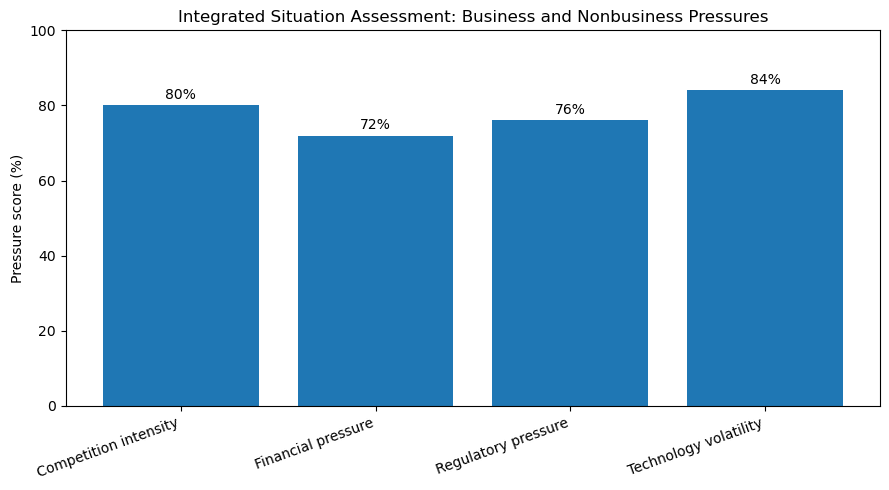

In [4]:
situation = pd.DataFrame({
    "Factor": [
        "Competition intensity",
        "Financial pressure",
        "Regulatory pressure",
        "Technology volatility"
    ],
    "Score": [80, 72, 76, 84],
    "Environment": ["Business", "Business", "Nonbusiness", "Nonbusiness"]
})

display(situation)

plt.figure(figsize=(9, 5))
bars = plt.bar(situation["Factor"], situation["Score"])
plt.title("Integrated Situation Assessment: Business and Nonbusiness Pressures")
plt.ylabel("Pressure score (%)")
plt.ylim(0, 100)
plt.xticks(rotation=20, ha="right")

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 1, f"{height:.0f}%", ha="center", va="bottom")

plt.tight_layout()
plt.savefig(FIG_DIR / "01_integrated_situation_assessment.png", dpi=300, bbox_inches="tight")
plt.show()

## 3. Qualitative Risk Assessment View

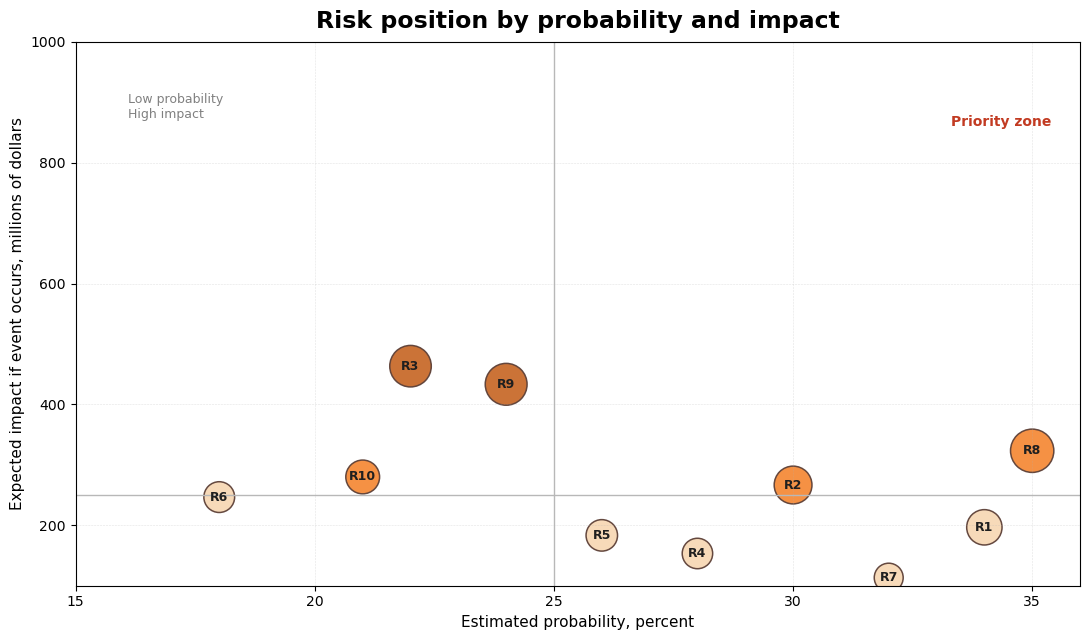

,Risk,Risk Name,Category,Mean Probability,Expected Impact $m,Expected Loss $m
0,Risk 1,Competitor AI Advantage,Strategic,0.34,196.666667,66.866667
1,Risk 2,AI Warehouse Strategy Failure,Strategic and operational,0.30,266.666667,80.000000
2,Risk 3,Cybersecurity & Data Breach,Information security,0.22,463.333333,101.933333
3,Risk 4,AI Forecasting Failure,Technology and operational,0.28,153.333333,42.933333
4,Risk 5,System Integration Failure,Technology and operational,0.26,183.333333,47.666667
5,Risk 6,Cloud Service Outage,Technology and continuity,0.18,246.666667,44.400000
6,Risk 7,Workforce Adoption Failure,People and change,0.32,113.333333,36.266667
7,Risk 8,Cost Overrun & Delayed ROI,Financial,0.35,323.333333,113.166667
8,Risk 9,Regulatory & Privacy Non Compliance,Compliance,0.24,433.333333,104.000000
9,Risk 10,AI Governance & Ethics Failure,Governance and compliance,0.21,280.000000,58.800000


In [17]:
import matplotlib.pyplot as plt
import numpy as np

# =========================
# Bubble chart (PPT style)
# =========================

fig, ax = plt.subplots(figsize=(11, 6.5))

colors = []
for _, row in quant.iterrows():
    if row["Expected Impact $m"] >= 400:
        colors.append("#c96b2c")     
    elif row["Expected Impact $m"] >= 250:
        colors.append("#f58b3a")      
    else:
        colors.append("#f7d8b5")      
sizes = quant["Expected Loss $m"] * 7 + 180

ax.scatter(
    quant["Mean Probability"] * 100,
    quant["Expected Impact $m"],
    s=sizes,
    c=colors,
    edgecolors="#5d4037",
    linewidths=1.1,
    alpha=0.95
)

for _, row in quant.iterrows():

    risk_id = row["Risk"].replace("Risk ", "R")

    ax.text(
        row["Mean Probability"] * 100,
        row["Expected Impact $m"],
        risk_id,
        ha="center",
        va="center",
        fontsize=9,
        fontweight="bold",
        color="#1f1f1f"
    )


ax.axvline(25, color="#b8b8b8", linewidth=1)
ax.axhline(250, color="#b8b8b8", linewidth=1)

# Priority Zone
ax.text(
    33.3,
    860,
    "Priority zone",
    fontsize=10,
    color="#c23b22",
    fontweight="bold"
)


ax.text(
    16.1,
    915,
    "Low probability\nHigh impact",
    fontsize=9,
    color="gray",
    ha="left",
    va="top"
)


ax.set_xlim(15, 36)
ax.set_ylim(100, 1000)

ax.set_xticks([15,20,25,30,35])
ax.set_yticks([200,400,600,800,1000])

ax.set_xlabel(
    "Estimated probability, percent",
    fontsize=11
)

ax.set_ylabel(
    "Expected impact if event occurs, millions of dollars",
    fontsize=11
)

ax.set_title(
    "Risk position by probability and impact",
    fontsize=17,
    fontweight="bold",
    pad=10
)

# 网格
ax.grid(
    True,
    linestyle="--",
    linewidth=0.4,
    alpha=0.35
)

plt.tight_layout()

plt.savefig(
    FIG_DIR / "02_qualitative_probability_impact.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

display(
    quant[
        [
            "Risk",
            "Risk Name",
            "Category",
            "Mean Probability",
            "Expected Impact $m",
            "Expected Loss $m"
        ]
    ]
)

## 4. Expected Loss Ranking

,Expected Loss Rank,Risk,Risk Name,Category,Mean Probability,Expected Impact $m,Expected Loss $m,P90 Loss $m,P95 Loss $m
7,1,Risk 8,Cost Overrun & Delayed ROI,Financial,0.35,323.333333,113.166667,176.323582,195.410793
8,2,Risk 9,Regulatory & Privacy Non Compliance,Compliance,0.24,433.333333,104.000000,169.112785,189.642911
2,3,Risk 3,Cybersecurity & Data Breach,Information security,0.22,463.333333,101.933333,164.592792,185.377677
1,4,Risk 2,AI Warehouse Strategy Failure,Strategic and operational,0.30,266.666667,80.000000,120.615209,133.316357
0,5,Risk 1,Competitor AI Advantage,Strategic,0.34,196.666667,66.866667,99.062378,108.826817
9,6,Risk 10,AI Governance & Ethics Failure,Governance and compliance,0.21,280.000000,58.800000,97.237690,110.149184
4,7,Risk 5,System Integration Failure,Technology and operational,0.26,183.333333,47.666667,73.045424,81.556982
5,8,Risk 6,Cloud Service Outage,Technology and continuity,0.18,246.666667,44.400000,71.604551,81.156893
3,9,Risk 4,AI Forecasting Failure,Technology and operational,0.28,153.333333,42.933333,66.476927,74.173550
6,10,Risk 7,Workforce Adoption Failure,People and change,0.32,113.333333,36.266667,55.823012,61.863027


Portfolio expected loss: 696.03 million USD


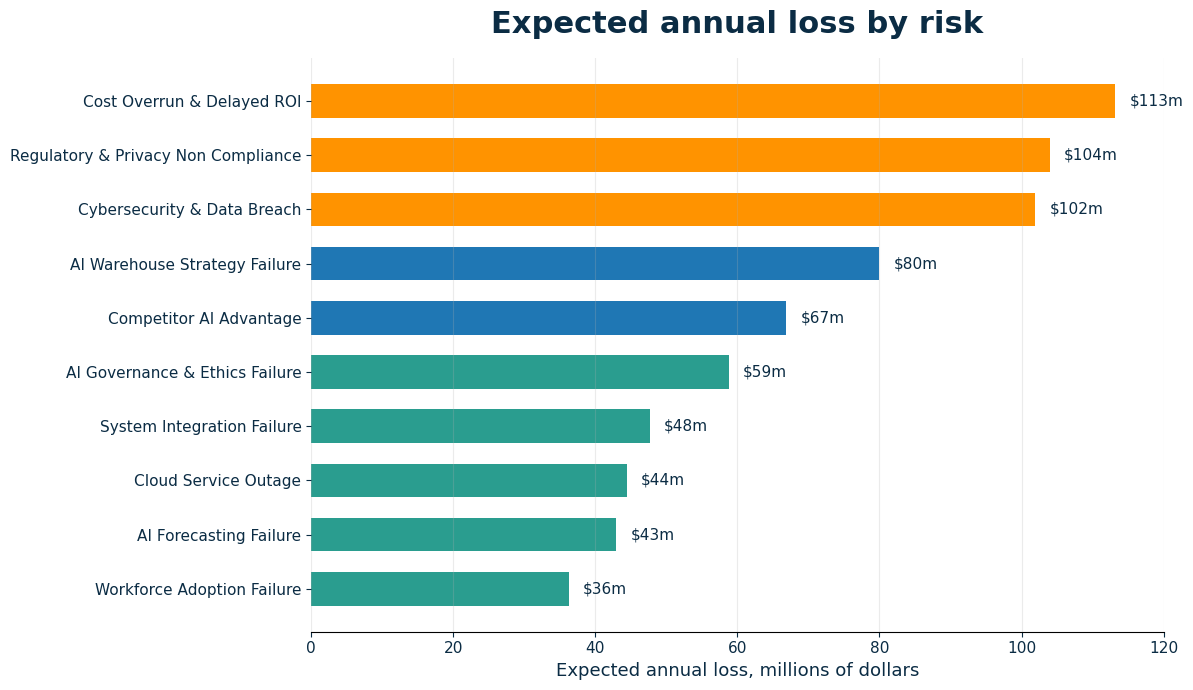

In [18]:
import matplotlib.pyplot as plt

quant_ranked = quant.copy()

quant_ranked["Expected Loss Rank"] = (
    quant_ranked["Expected Loss $m"]
    .rank(ascending=False, method="dense")
    .astype(int)
)

quant_ranked = quant_ranked.sort_values("Expected Loss $m", ascending=False)

display(
    quant_ranked[
        [
            "Expected Loss Rank",
            "Risk",
            "Risk Name",
            "Category",
            "Mean Probability",
            "Expected Impact $m",
            "Expected Loss $m",
            "P90 Loss $m",
            "P95 Loss $m",
        ]
    ]
)

portfolio_expected_loss = quant_ranked["Expected Loss $m"].sum()

print(
    "Portfolio expected loss:",
    round(portfolio_expected_loss, 2),
    "million USD"
)

# Match PPT color style
colors = []
for i in range(len(quant_ranked)):
    if i < 3:
        colors.append("#ff9300")   # orange: top 3 risks
    elif i < 5:
        colors.append("#1f77b4")   # blue: next strategic risks
    else:
        colors.append("#2a9d8f")   # teal: remaining risks

fig, ax = plt.subplots(figsize=(12, 7))

bars = ax.barh(
    quant_ranked["Risk Name"],
    quant_ranked["Expected Loss $m"],
    color=colors,
    height=0.62
)

ax.invert_yaxis()

ax.set_title(
    "Expected annual loss by risk",
    fontsize=22,
    fontweight="bold",
    color="#0b2c44",
    pad=18
)

ax.set_xlabel(
    "Expected annual loss, millions of dollars",
    fontsize=13,
    color="#0b2c44"
)

ax.set_xlim(0, 120)
ax.set_xticks(range(0, 121, 20))

ax.grid(
    axis="x",
    linestyle="-",
    linewidth=0.8,
    alpha=0.25
)

ax.tick_params(axis="x", labelsize=11, colors="#0b2c44")
ax.tick_params(axis="y", labelsize=11, colors="#0b2c44")

for bar in bars:
    width = bar.get_width()
    ax.text(
        width + 2,
        bar.get_y() + bar.get_height() / 2,
        f"${width:.0f}m",
        va="center",
        ha="left",
        fontsize=11,
        color="#0b2c44"
    )

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)

plt.tight_layout()

plt.savefig(
    FIG_DIR / "03_expected_loss_ranking.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 5. Top Quantified Exposures

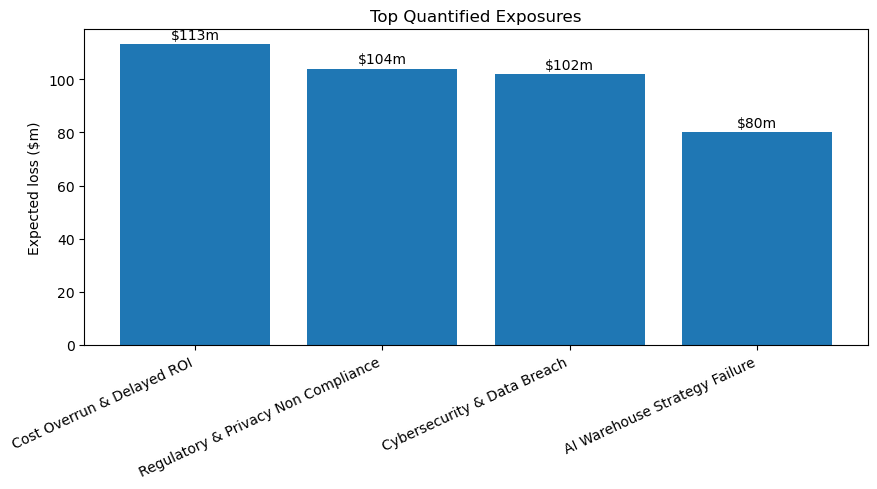

In [7]:
top4 = quant_ranked.head(4).copy()

plt.figure(figsize=(9, 5))
bars = plt.bar(top4["Risk Name"], top4["Expected Loss $m"])
plt.title("Top Quantified Exposures")
plt.ylabel("Expected loss ($m)")
plt.xticks(rotation=25, ha="right")

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 1, f"${height:.0f}m", ha="center", va="bottom")

plt.tight_layout()
plt.savefig(FIG_DIR / "04_top_quantified_exposures.png", dpi=300, bbox_inches="tight")
plt.show()

## 6. ML-Based Risk Prediction: Model Validation

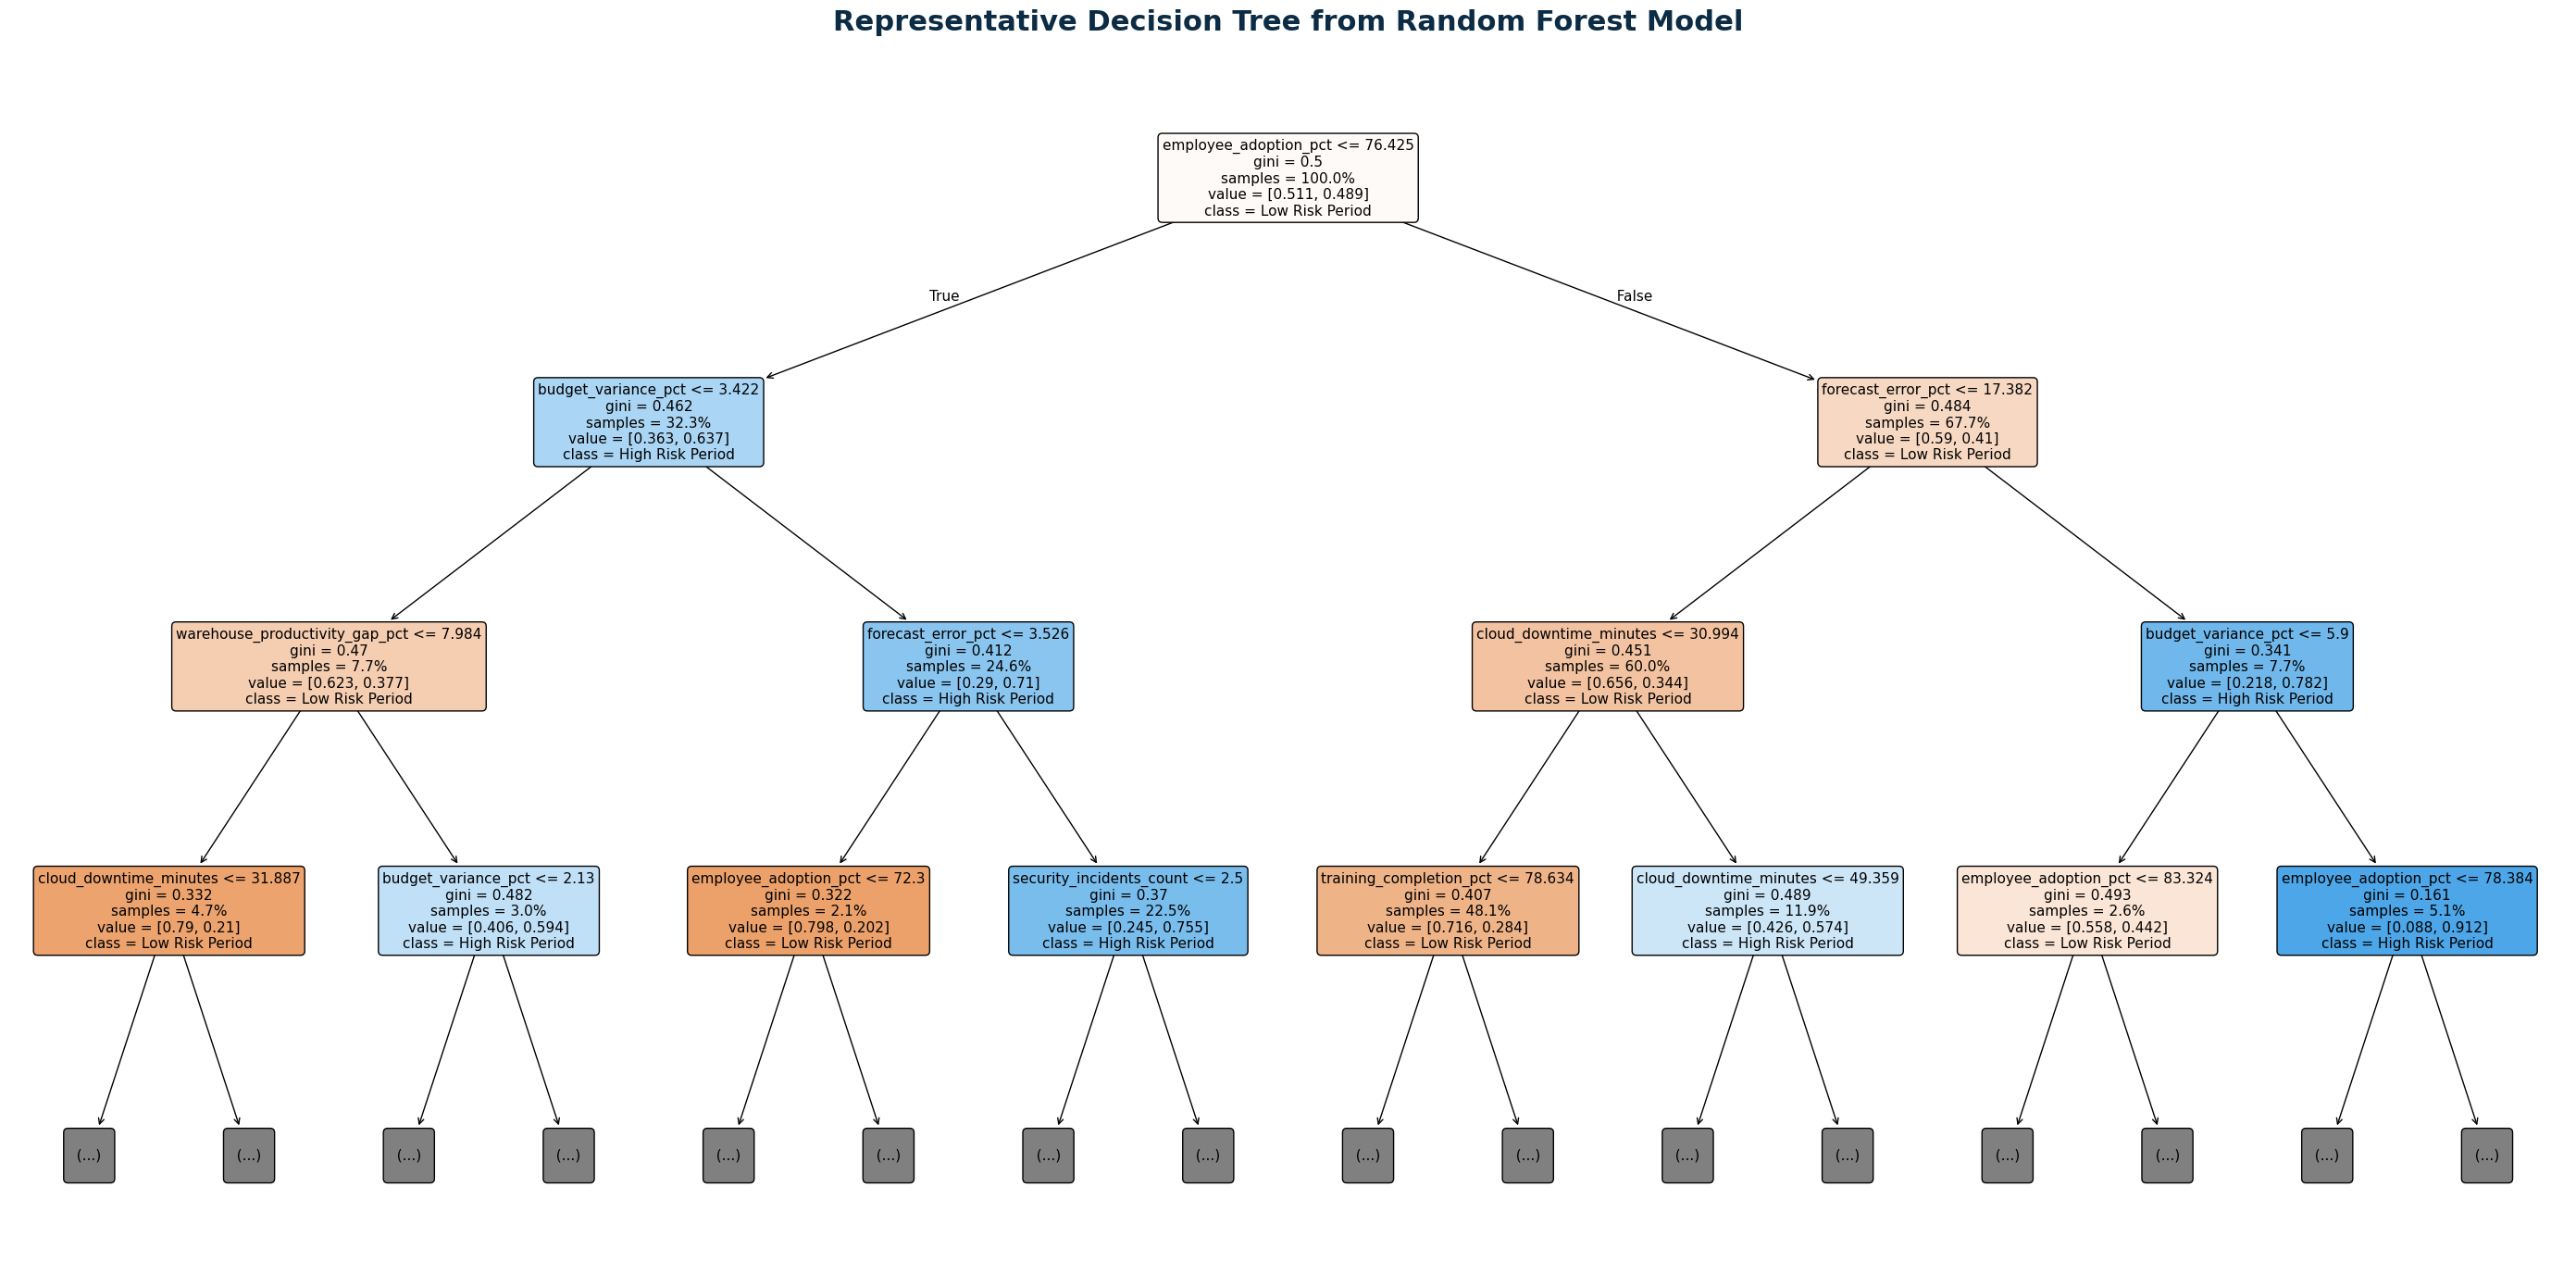


Interpretation

This figure shows one representative decision tree extracted from the Random Forest model.

Although the Random Forest contains 100 decision trees, this example illustrates how
budget variance, forecast error, employee adoption, and warehouse productivity are
combined to classify observations into high-risk and low-risk periods.

The following feature importance analysis summarizes the contribution of all trees in
the forest.



In [25]:
# ==========================================
# Random Forest Tree Visualization
# ==========================================

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import plot_tree

# Load synthetic ML dataset
ml = pd.read_csv("synthetic_ml_dataset.csv")

# Target variable
target_col = "high_loss_event"

# Features
X = ml.drop(columns=[target_col])
y = ml[target_col]

# Train / test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

# Train Random Forest model
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=4,
    random_state=42,
    class_weight="balanced"
)

rf_model.fit(X_train, y_train)

# Select one tree from the random forest
single_tree = rf_model.estimators_[0]

# Plot one representative tree
plt.figure(figsize=(28, 14))

plot_tree(
    single_tree,
    feature_names=X.columns,
    class_names=["Low Risk Period", "High Risk Period"],
    filled=True,
    rounded=True,
    max_depth=3,
    fontsize=11,
    proportion=True
)

plt.title(
    "Representative Decision Tree from Random Forest Model",
    fontsize=22,
    fontweight="bold",
    color="#0b2c44",
    pad=20
)

plt.tight_layout()

plt.savefig(
    FIG_DIR / "08_random_forest_representative_tree.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
print(
"""
Interpretation

This figure shows one representative decision tree extracted from the Random Forest model.

Although the Random Forest contains 100 decision trees, this example illustrates how
budget variance, forecast error, employee adoption, and warehouse productivity are
combined to classify observations into high-risk and low-risk periods.

The following feature importance analysis summarizes the contribution of all trees in
the forest.
"""
)

In [27]:
# ---------------------------------------------------------
# Random Forest Performance Evaluation
# ---------------------------------------------------------

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

# Predict on the test set
rf_pred = rf_model.predict(X_test)
rf_prob = rf_model.predict_proba(X_test)[:, 1]

# Calculate metrics
rf_accuracy = accuracy_score(y_test, rf_pred)
rf_precision = precision_score(y_test, rf_pred)
rf_recall = recall_score(y_test, rf_pred)
rf_f1 = f1_score(y_test, rf_pred)
rf_auc = roc_auc_score(y_test, rf_prob)

# Display metrics
rf_metrics = pd.DataFrame({
    "Metric":[
        "ROC AUC",
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ],
    "Random Forest":[
        rf_auc,
        rf_accuracy,
        rf_precision,
        rf_recall,
        rf_f1
    ]
})

display(rf_metrics.style.format({"Random Forest":"{:.3f}"}))

print("\nClassification Report")
print(classification_report(y_test, rf_pred))

,Metric,Random Forest
0,ROC AUC,0.804
1,Accuracy,0.737
2,Precision,0.631
3,Recall,0.694
4,F1 Score,0.661



Classification Report
              precision    recall  f1-score   support

           0       0.81      0.76      0.78       189
           1       0.63      0.69      0.66       111

    accuracy                           0.74       300
   macro avg       0.72      0.73      0.72       300
weighted avg       0.74      0.74      0.74       300



,Model,ROC AUC,Accuracy,Precision,Recall,F1
0,Logistic regression,0.857381,0.760000,0.648855,0.765766,0.702479
1,Random forest,0.813814,0.723333,0.620690,0.648649,0.634361


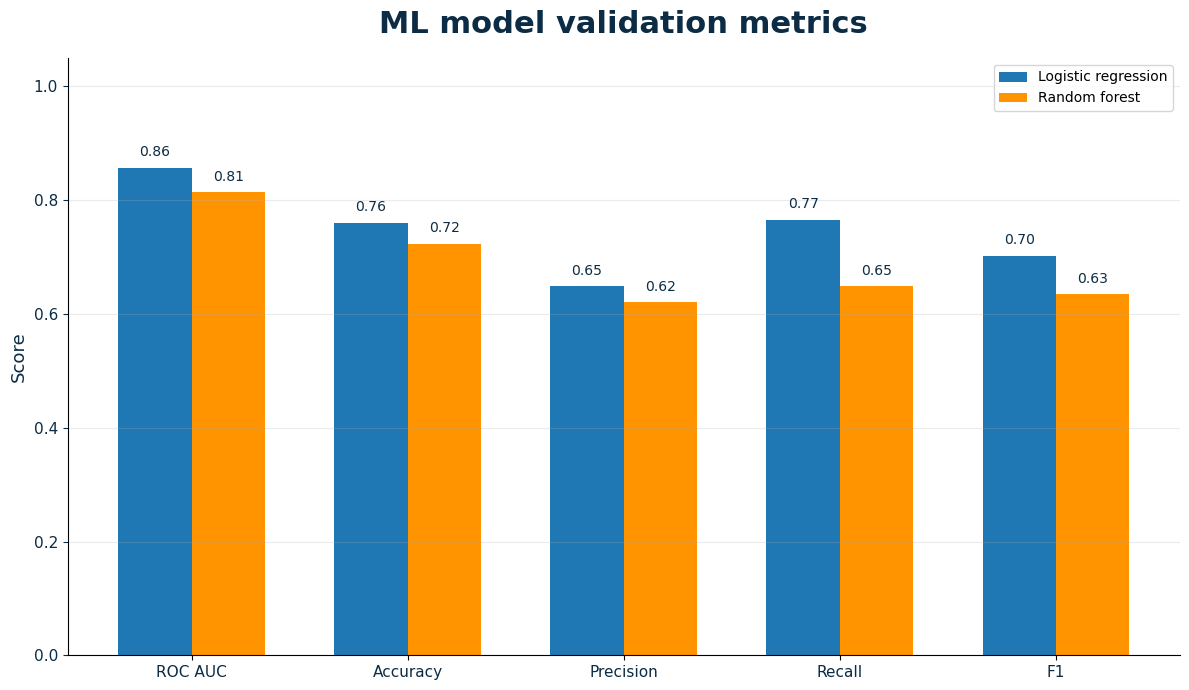

In [31]:
# ---------------------------------------------------------
# ML Model Validation Metrics
# Recalculate Logistic Regression + Random Forest results
# ---------------------------------------------------------

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    roc_auc_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# Load data
ml = pd.read_csv("synthetic_ml_dataset.csv")

# Target column
target_col = "high_loss_event"

X = ml.drop(columns=[target_col])
y = ml[target_col]

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

# Models
models = {
    "Logistic regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=1000, class_weight="balanced"))
    ]),
    "Random forest": RandomForestClassifier(
        n_estimators=200,
        max_depth=5,
        random_state=42,
        class_weight="balanced"
    )
}

# Calculate metrics
rows = []

for model_name, model in models.items():
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    rows.append({
        "Model": model_name,
        "ROC AUC": roc_auc_score(y_test, y_prob),
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred)
    })

ml_metrics_recalculated = pd.DataFrame(rows)

display(ml_metrics_recalculated)

# ---------------------------------------------------------
# Plot: PPT-style model validation chart
# ---------------------------------------------------------

metric_cols = ["ROC AUC", "Accuracy", "Precision", "Recall", "F1"]

x = np.arange(len(metric_cols))
width = 0.34

fig, ax = plt.subplots(figsize=(12, 7))

colors = {
    "Logistic regression": "#1f77b4",
    "Random forest": "#ff9300"
}

for i, model_name in enumerate(ml_metrics_recalculated["Model"]):
    values = ml_metrics_recalculated.loc[
        ml_metrics_recalculated["Model"] == model_name,
        metric_cols
    ].iloc[0].values

    bars = ax.bar(
        x + (i - 0.5) * width,
        values,
        width,
        label=model_name,
        color=colors.get(model_name, "#2a9d8f")
    )

    for bar in bars:
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width()/2,
            height + 0.015,
            f"{height:.2f}",
            ha="center",
            va="bottom",
            fontsize=10,
            color="#0b2c44"
        )

ax.set_title(
    "ML model validation metrics",
    fontsize=22,
    fontweight="bold",
    color="#0b2c44",
    pad=18
)

ax.set_ylabel(
    "Score",
    fontsize=13,
    color="#0b2c44"
)

ax.set_ylim(0, 1.05)
ax.set_xticks(x)
ax.set_xticklabels(metric_cols, fontsize=11, color="#0b2c44")

ax.tick_params(axis="y", labelsize=11, colors="#0b2c44")

ax.grid(
    axis="y",
    linestyle="-",
    linewidth=0.8,
    alpha=0.25
)

ax.legend(frameon=True)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()

plt.savefig(
    FIG_DIR / "05_ml_model_validation_metrics.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

,Model,ROC AUC,Accuracy,Precision,Recall,F1
0,Logistic regression,0.851473,0.763889,0.652174,0.783582,0.711864
1,Random forest,0.812409,0.733333,0.637681,0.656716,0.647059


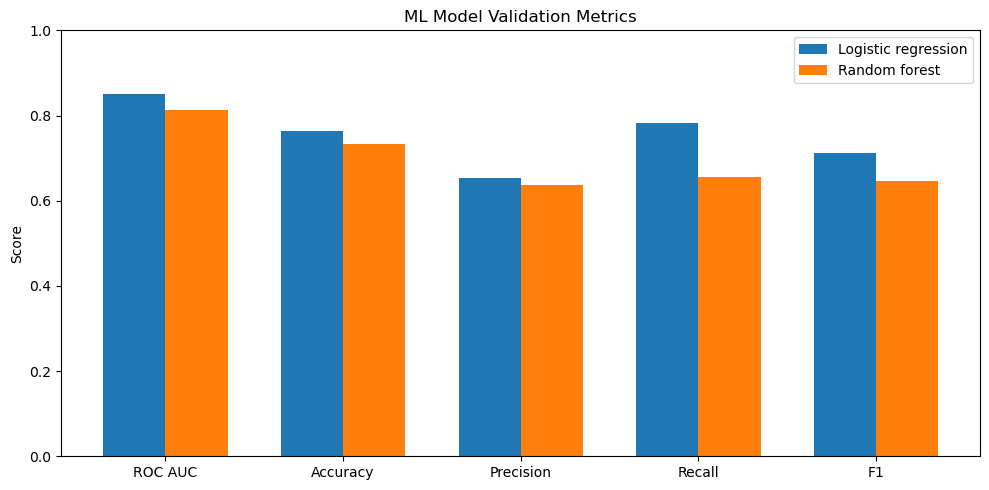

In [8]:
display(ml_metrics)

metric_cols = ["ROC AUC", "Accuracy", "Precision", "Recall", "F1"]

plt.figure(figsize=(10, 5))
x = np.arange(len(metric_cols))
width = 0.35

for i, model in enumerate(ml_metrics["Model"]):
    values = ml_metrics.loc[ml_metrics["Model"] == model, metric_cols].iloc[0].values
    plt.bar(x + (i - 0.5) * width, values, width, label=model)

plt.title("ML Model Validation Metrics")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(x, metric_cols)
plt.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "05_ml_model_validation_metrics.png", dpi=300, bbox_inches="tight")
plt.show()

## 7. ML Feature Importance

,Feature,Importance
0,budget_variance_pct,0.172064
1,forecast_error_pct,0.159784
2,warehouse_productivity_gap_pct,0.139949
3,employee_adoption_pct,0.135612
4,cloud_downtime_minutes,0.105584
5,training_completion_pct,0.071747
6,open_compliance_gaps,0.066526
7,security_incidents_count,0.043921
8,integration_defects_count,0.041147
9,bias_reports_count,0.040595


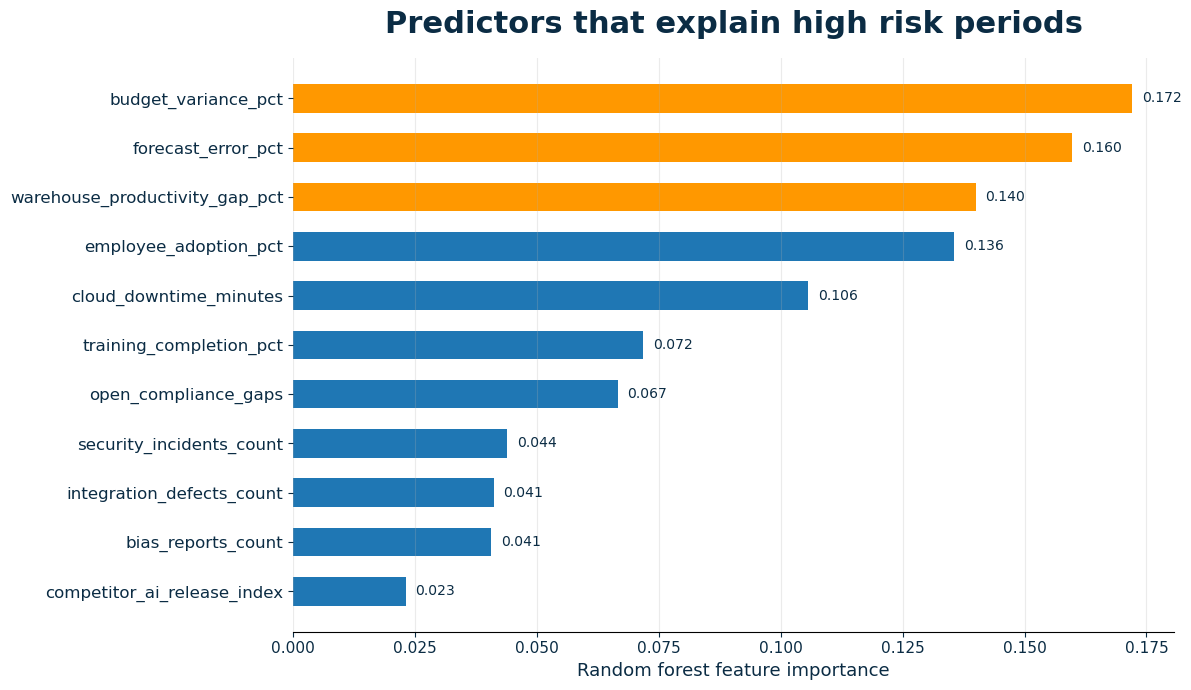

In [19]:
import matplotlib.pyplot as plt

feature_importance_sorted = feature_importance.sort_values(
    "Importance",
    ascending=False
)

display(feature_importance_sorted)

colors = [
    "#ff9800" if i < 3 else "#1f77b4"
    for i in range(len(feature_importance_sorted))
]

fig, ax = plt.subplots(figsize=(12, 7))

bars = ax.barh(
    feature_importance_sorted["Feature"],
    feature_importance_sorted["Importance"],
    color=colors,
    height=0.58
)


ax.invert_yaxis()
ax.set_title(
    "Predictors that explain high risk periods",
    fontsize=22,
    fontweight="bold",
    color="#0b2c44",
    pad=18
)

ax.set_xlabel(
    "Random forest feature importance",
    fontsize=13,
    color="#0b2c44"
)

ax.grid(
    axis="x",
    linestyle="-",
    linewidth=0.8,
    alpha=0.25
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)

ax.tick_params(axis="x", labelsize=11, colors="#0b2c44")
ax.tick_params(axis="y", labelsize=12, colors="#0b2c44")

for bar in bars:
    width = bar.get_width()
    ax.text(
        width + 0.002,
        bar.get_y() + bar.get_height()/2,
        f"{width:.3f}",
        va="center",
        fontsize=10,
        color="#0b2c44"
    )

plt.tight_layout()

plt.savefig(
    FIG_DIR / "06_ml_feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 8. Logistic Regression Coefficients

,Feature,Standardized coefficient
0,budget_variance_pct,0.889582
1,forecast_error_pct,0.704790
2,open_compliance_gaps,0.685830
4,warehouse_productivity_gap_pct,0.623746
5,bias_reports_count,0.590577
6,security_incidents_count,0.560500
7,cloud_downtime_minutes,0.504154
8,integration_defects_count,0.355324
10,competitor_ai_release_index,0.301346
9,training_completion_pct,-0.327604


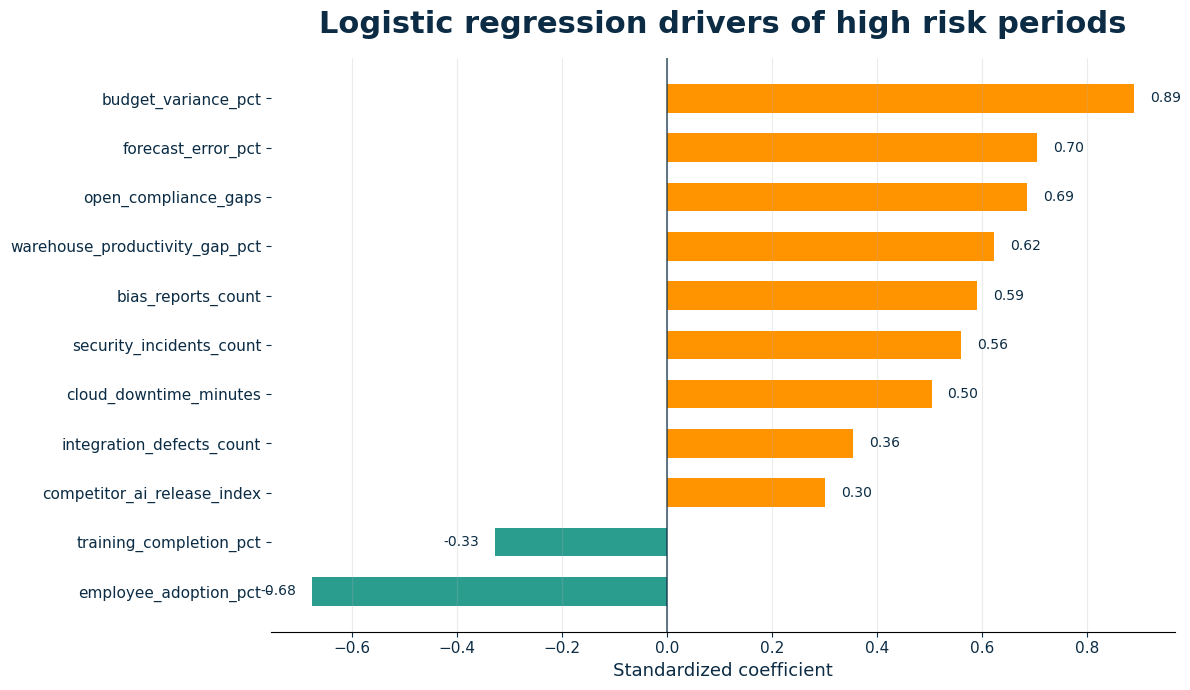

In [20]:
import matplotlib.pyplot as plt

coef_sorted = logistic_coef.sort_values(
    "Standardized coefficient",
    ascending=True
)

display(
    logistic_coef.sort_values(
        "Standardized coefficient",
        ascending=False
    )
)

colors = [
    "#ff9300" if value > 0 else "#2a9d8f"
    for value in coef_sorted["Standardized coefficient"]
]

fig, ax = plt.subplots(figsize=(12, 7))

bars = ax.barh(
    coef_sorted["Feature"],
    coef_sorted["Standardized coefficient"],
    color=colors,
    height=0.58
)

ax.axvline(
    0,
    color="#0b2c44",
    linewidth=1.2,
    alpha=0.75
)

ax.set_title(
    "Logistic regression drivers of high risk periods",
    fontsize=22,
    fontweight="bold",
    color="#0b2c44",
    pad=18
)

ax.set_xlabel(
    "Standardized coefficient",
    fontsize=13,
    color="#0b2c44"
)

ax.grid(
    axis="x",
    linestyle="-",
    linewidth=0.8,
    alpha=0.25
)

ax.tick_params(axis="x", labelsize=11, colors="#0b2c44")
ax.tick_params(axis="y", labelsize=11, colors="#0b2c44")

for bar in bars:
    width = bar.get_width()
    y = bar.get_y() + bar.get_height() / 2

    if width >= 0:
        ax.text(
            width + 0.03,
            y,
            f"{width:.2f}",
            va="center",
            ha="left",
            fontsize=10,
            color="#0b2c44"
        )
    else:
        ax.text(
            width - 0.03,
            y,
            f"{width:.2f}",
            va="center",
            ha="right",
            fontsize=10,
            color="#0b2c44"
        )

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)

plt.tight_layout()

plt.savefig(
    FIG_DIR / "07_logistic_coefficients.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 9. Monte Carlo Simulation – 100,000 Trials

In [11]:
rng = np.random.default_rng(6130)
n_trials = 100_000

risk_loss_matrix = pd.DataFrame(index=np.arange(n_trials))

for _, row in quant.iterrows():
    risk_name = row["Risk Name"]

    # Probability uncertainty: beta distribution
    p = rng.beta(row["Beta alpha"], row["Beta beta"], size=n_trials)

    # Event occurrence: Bernoulli trials using uncertain probability
    occurs = rng.binomial(1, p)

    # Impact uncertainty: triangular distribution
    impact = rng.triangular(
        left=row["Impact min $m"],
        mode=row["Impact mode $m"],
        right=row["Impact max $m"],
        size=n_trials
    )

    risk_loss_matrix[risk_name] = occurs * impact

annual_loss = risk_loss_matrix.sum(axis=1)

sim_summary = pd.DataFrame({
    "Mean annual loss $m": [annual_loss.mean()],
    "Median annual loss $m": [np.percentile(annual_loss, 50)],
    "P75 annual loss $m": [np.percentile(annual_loss, 75)],
    "P90 annual loss $m": [np.percentile(annual_loss, 90)],
    "P95 annual loss $m": [np.percentile(annual_loss, 95)],
    "P99 annual loss $m": [np.percentile(annual_loss, 99)],
    "Probability loss above 500m": [(annual_loss > 500).mean()],
    "Probability loss above 1000m": [(annual_loss > 1000).mean()]
})

print("Recreated Monte Carlo simulation summary:")
display(sim_summary.round(4))

print("Provided Monte Carlo summary from CSV:")
display(mc_summary.round(4))

Recreated Monte Carlo simulation summary:


,Mean annual loss $m,Median annual loss $m,P75 annual loss $m,P90 annual loss $m,P95 annual loss $m,P99 annual loss $m,Probability loss above 500m,Probability loss above 1000m
0,695.3097,644.4752,961.2647,1274.2817,1479.265,1875.0689,0.636,0.2266


Provided Monte Carlo summary from CSV:


,Mean annual loss $m,Median annual loss $m,P75 annual loss $m,P90 annual loss $m,P95 annual loss $m,P99 annual loss $m,Probability loss above 500m,Probability loss above 1000m
0,718.7276,654.0662,1002.8605,1356.917,1585.8938,2046.5792,0.6333,0.2516


## 10. Monte Carlo Annual Loss Distribution

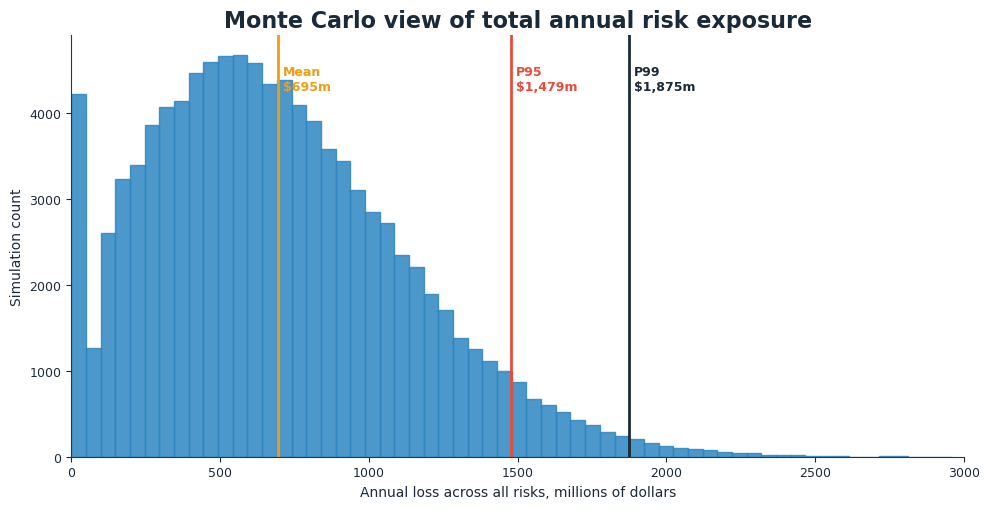

In [29]:
# Monte Carlo annual loss distribution - slide style version

mean_loss = annual_loss.mean()
p95_loss = np.percentile(annual_loss, 95)
p99_loss = np.percentile(annual_loss, 99)

fig, ax = plt.subplots(figsize=(10, 5.2))

# Histogram
ax.hist(
    annual_loss,
    bins=60,
    color="#2E86C1",
    alpha=0.85,
    edgecolor="#2E86C1"
)

# Vertical reference lines
ax.axvline(mean_loss, color="#F39C12", linewidth=2)
ax.axvline(p95_loss, color="#E74C3C", linewidth=2)
ax.axvline(p99_loss, color="#1B2A38", linewidth=2)

# Labels on top
ymax = ax.get_ylim()[1]

ax.text(
    mean_loss + 15, ymax * 0.93,
    f"Mean\n${mean_loss:,.0f}m",
    color="#F39C12",
    fontsize=9,
    fontweight="bold",
    va="top"
)

ax.text(
    p95_loss + 15, ymax * 0.93,
    f"P95\n${p95_loss:,.0f}m",
    color="#E74C3C",
    fontsize=9,
    fontweight="bold",
    va="top"
)

ax.text(
    p99_loss + 15, ymax * 0.93,
    f"P99\n${p99_loss:,.0f}m",
    color="#1B2A38",
    fontsize=9,
    fontweight="bold",
    va="top"
)

# Title and axis labels
ax.set_title(
    "Monte Carlo view of total annual risk exposure",
    fontsize=16,
    fontweight="bold",
    color="#1B2A38"
)

ax.set_xlabel(
    "Annual loss across all risks, millions of dollars",
    fontsize=10,
    color="#1B2A38"
)

ax.set_ylabel(
    "Simulation count",
    fontsize=10,
    color="#1B2A38"
)

# Style
ax.set_xlim(0, 3000)
ax.grid(False)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color("#333333")
ax.spines["bottom"].set_color("#333333")

ax.tick_params(axis="both", labelsize=9, colors="#1B2A38")

plt.tight_layout()

plt.savefig(
    FIG_DIR / "08_monte_carlo_annual_loss_distribution.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

## 11. Exceedance Probability Chart

,Threshold,Probability
0,>$500m,0.63597
1,>$1000m,0.22661
2,>$1500m,0.04600
3,>$2000m,0.00559


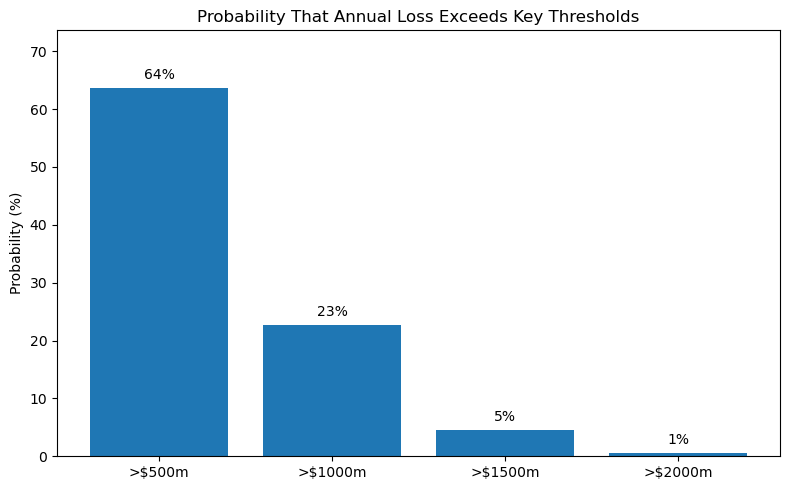

In [13]:
thresholds = [500, 1000, 1500, 2000]
exceedance = pd.DataFrame({
    "Threshold": [f">${t}m" for t in thresholds],
    "Probability": [(annual_loss > t).mean() for t in thresholds]
})

display(exceedance)

plt.figure(figsize=(8, 5))
bars = plt.bar(exceedance["Threshold"], exceedance["Probability"] * 100)
plt.title("Probability That Annual Loss Exceeds Key Thresholds")
plt.ylabel("Probability (%)")
plt.ylim(0, max(exceedance["Probability"] * 100) + 10)

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 1, f"{height:.0f}%", ha="center", va="bottom")

plt.tight_layout()
plt.savefig(FIG_DIR / "09_exceedance_probability.png", dpi=300, bbox_inches="tight")
plt.show()

## 12. Severe Loss Contribution

Recreated tail contribution from simulated severe-loss scenarios:


,Risk,Tail contribution
0,Cybersecurity & Data Breach,0.231456
1,Regulatory & Privacy Non Compliance,0.210394
2,Cost Overrun & Delayed ROI,0.146988
3,AI Warehouse Strategy Failure,0.094000
4,AI Governance & Ethics Failure,0.082963
5,Competitor AI Advantage,0.062305
6,Cloud Service Outage,0.056466
7,System Integration Failure,0.046956
8,AI Forecasting Failure,0.039725
9,Workforce Adoption Failure,0.028747


Provided tail contribution from CSV:


,Risk,Tail contribution
2,Cybersecurity & Data Breach,0.223794
8,Regulatory & Privacy Non Compliance,0.201221
7,Cost Overrun & Delayed ROI,0.141564
1,AI Warehouse Strategy Failure,0.095440
9,AI Governance & Ethics Failure,0.090851
0,Competitor AI Advantage,0.061893
5,Cloud Service Outage,0.059811
4,System Integration Failure,0.052285
3,AI Forecasting Failure,0.042933
6,Workforce Adoption Failure,0.030207


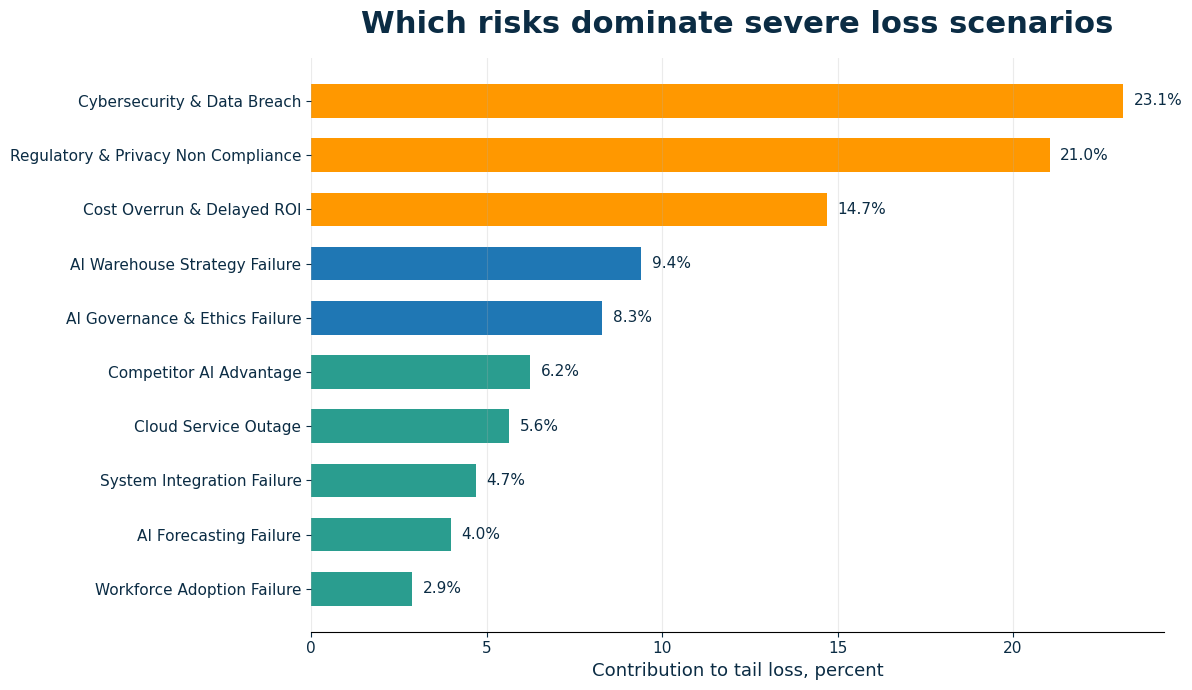

In [21]:
# ==========================
# Tail Risk Contribution
# ==========================

tail_threshold = np.percentile(annual_loss, 95)
tail_scenarios = risk_loss_matrix.loc[annual_loss >= tail_threshold]

tail_contribution_sim = (
    tail_scenarios.sum(axis=0)
    / tail_scenarios.sum(axis=0).sum()
).sort_values(ascending=False)

tail_contribution_sim_df = tail_contribution_sim.reset_index()
tail_contribution_sim_df.columns = ["Risk", "Tail contribution"]

print("Recreated tail contribution from simulated severe-loss scenarios:")
display(tail_contribution_sim_df)

print("Provided tail contribution from CSV:")
display(tail.sort_values("Tail contribution", ascending=False))

# ----------------------------------
# Plot (PPT style)
# ----------------------------------

plot_tail = tail_contribution_sim_df.sort_values(
    "Tail contribution",
    ascending=False
)

colors = []

for i in range(len(plot_tail)):
    if i < 3:
        colors.append("#ff9800")      # Orange
    elif i < 5:
        colors.append("#1f77b4")      # Blue
    else:
        colors.append("#2a9d8f")      # Teal

fig, ax = plt.subplots(figsize=(12, 7))

bars = ax.barh(
    plot_tail["Risk"],
    plot_tail["Tail contribution"] * 100,
    color=colors,
    height=0.62
)

ax.invert_yaxis()

ax.set_title(
    "Which risks dominate severe loss scenarios",
    fontsize=22,
    fontweight="bold",
    color="#0b2c44",
    pad=18
)

ax.set_xlabel(
    "Contribution to tail loss, percent",
    fontsize=13,
    color="#0b2c44"
)

ax.grid(
    axis="x",
    linestyle="-",
    linewidth=0.8,
    alpha=0.25
)

ax.tick_params(
    axis="x",
    labelsize=11,
    colors="#0b2c44"
)

ax.tick_params(
    axis="y",
    labelsize=11,
    colors="#0b2c44"
)

for bar in bars:

    width = bar.get_width()

    ax.text(
        width + 0.3,
        bar.get_y() + bar.get_height()/2,
        f"{width:.1f}%",
        va="center",
        ha="left",
        fontsize=11,
        color="#0b2c44"
    )

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)

plt.tight_layout()

plt.savefig(
    FIG_DIR / "10_severe_loss_contribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 13. KRI Trigger Table

In [15]:
kri_table = pd.DataFrame({
    "Risk area": [
        "AI competition",
        "Warehouse AI",
        "Cybersecurity",
        "Forecasting",
        "Cloud outage",
        "Workforce adoption",
        "Cost and ROI",
        "Compliance and ethics"
    ],
    "KRI": [
        "Competitor AI release index",
        "Productivity gap",
        "Security incident count",
        "Forecast error rate",
        "System uptime",
        "Employee adoption rate",
        "Budget variance",
        "Open gaps or bias reports"
    ],
    "Trigger for action": [
        "Two major rival releases in a quarter",
        "Gap exceeds 10 percent for two weeks",
        "Any major breach or repeated alerts",
        "Error above 15 percent",
        "Below 99.9 percent",
        "Below 75 percent",
        "Above 15 percent",
        "Any unresolved high severity issue"
    ]
})

display(kri_table)

,Risk area,KRI,Trigger for action
0,AI competition,Competitor AI release index,Two major rival releases in a quarter
1,Warehouse AI,Productivity gap,Gap exceeds 10 percent for two weeks
2,Cybersecurity,Security incident count,Any major breach or repeated alerts
3,Forecasting,Forecast error rate,Error above 15 percent
4,Cloud outage,System uptime,Below 99.9 percent
5,Workforce adoption,Employee adoption rate,Below 75 percent
6,Cost and ROI,Budget variance,Above 15 percent
7,Compliance and ethics,Open gaps or bias reports,Any unresolved high severity issue


## 14. Exported Figure Files

In [33]:
print("Generated figure files:")
for file in sorted(FIG_DIR.glob("*.png")):
    print(file)

Generated figure files:
figures\01_integrated_situation_assessment.png
figures\02_qualitative_probability_impact.png
figures\03_expected_loss_ranking.png
figures\04_top_quantified_exposures.png
figures\05_ml_model_validation_metrics.png
figures\06_ml_feature_importance.png
figures\07_logistic_coefficients.png
figures\08_monte_carlo_annual_loss_distribution.png
figures\08_random_forest_representative_tree.png
figures\09_exceedance_probability.png
figures\10_severe_loss_contribution.png


## Final Notes

This notebook connects the PPT content to reproducible analytics outputs.

The Monte Carlo results may differ slightly from the provided `monte_carlo_summary.csv` because this notebook reconstructs the simulation from the risk probability and impact assumptions using a random seed. The direction and interpretation should remain consistent with the PPT: average annual exposure is substantial, and tail-risk exposure is much wider than the mean alone.